# Статистический анализ данных, проверка гипотез

### Описание проекта

Аналитика популярного сервиса аренды самокатов GoFast. В распоряжении данные о некоторых пользователях из нескольких городов, а также об их поездках. 

Чтобы совершать поездки по городу, пользователи сервиса GoFast пользуются мобильным приложением. Сервисом можно пользоваться:
* без подписки
    * абонентская плата отсутствует;
    * стоимость одной минуты поездки — 8 рублей;
    * стоимость старта (начала поездки) — 50 рублей.      
* с подпиской Ultra
    * абонентская плата — 199 рублей в месяц;
    * стоимость одной минуты поездки — 6 рублей;
    * стоимость старта — бесплатно.

### Цель проекта

Проанализировать данные и проверить гипотезы, которые могут помочь бизнесу вырасти.
* Тратят ли пользователи с подпиской больше времени на поездки? 
* Можно ли сказать, что среднее расстояние, которое проезжают пользователи с подпиской за одну поездку, не превышает 3130 метров (оптимальное с точки зрения износа самоката)? 
* Будет ли помесячная выручка от пользователей с подпиской по месяцам выше, чем выручка от пользователей без подписки?


### Описание данных
В основных данных есть информация о пользователях, их поездках и подписках.

Пользователи — users_go.csv
* user_id - уникальный идентификатор пользователя
* name - имя пользователя
* age - возраст
* city - город
* subscription_type - тип подписки (free, ultra)

Поездки — rides_go.csv
* user_id - уникальный идентификатор пользователя
* distance - расстояние, которое пользователь проехал в текущей сессии (в метрах)
* duration - продолжительность сессии (в минутах) — время с того момента, как пользователь нажал кнопку «Начать поездку» до момента, как он нажал кнопку «Завершить поездку»
* date - дата совершения поездки

Подписки — subscriptions_go.csv
* subscription_type - тип подписки
* minute_price - стоимость одной минуты поездки по данной подписке
* start_ride_price - стоимость начала поездки
* subscription_fee - стоимость ежемесячного платежа

## Загрузка данных

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as st

In [3]:
users = pd.read_csv('users_go.csv')
users.head()

,user_id,name,age,city,subscription_type
0,1,Кира,22,Тюмень,ultra
1,2,Станислав,31,Омск,ultra
2,3,Алексей,20,Москва,ultra
3,4,Константин,26,Ростов-на-Дону,ultra
4,5,Адель,28,Омск,ultra


In [4]:
users.info()

<class 'pandas.DataFrame'>
RangeIndex: 1565 entries, 0 to 1564
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   user_id            1565 non-null   int64
 1   name               1565 non-null   str  
 2   age                1565 non-null   int64
 3   city               1565 non-null   str  
 4   subscription_type  1565 non-null   str  
dtypes: int64(2), str(3)
memory usage: 61.3 KB


In [5]:
users.describe()

,user_id,age
count,1565.000000,1565.000000
mean,762.633866,24.922045
std,443.260155,4.553496
min,1.000000,12.000000
25%,378.000000,22.000000
50%,762.000000,25.000000
75%,1146.000000,28.000000
max,1534.000000,43.000000


In [6]:
rides = pd.read_csv('rides_go.csv')
rides.head()

,user_id,distance,duration,date
0,1,4409.919140,25.599769,2021-01-01
1,1,2617.592153,15.816871,2021-01-18
2,1,754.159807,6.232113,2021-04-20
3,1,2694.783254,18.511000,2021-08-11
4,1,4028.687306,26.265803,2021-08-28


In [7]:
rides.info()

<class 'pandas.DataFrame'>
RangeIndex: 18068 entries, 0 to 18067
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   user_id   18068 non-null  int64  
 1   distance  18068 non-null  float64
 2   duration  18068 non-null  float64
 3   date      18068 non-null  str    
dtypes: float64(2), int64(1), str(1)
memory usage: 564.8 KB


In [8]:
rides.describe()

,user_id,distance,duration
count,18068.000000,18068.000000,18068.000000
mean,842.869936,3070.659976,17.805011
std,434.734317,1116.831209,6.091051
min,1.000000,0.855683,0.500000
25%,487.000000,2543.226360,13.597563
50%,889.000000,3133.609994,17.678395
75%,1213.250000,3776.222735,21.724800
max,1534.000000,7211.007745,40.823963


In [9]:
subscriptions = pd.read_csv('subscriptions_go.csv')
subscriptions.head()

,subscription_type,minute_price,start_ride_price,subscription_fee
0,free,8,50,0
1,ultra,6,0,199


В датафрейме users содержится информация о 1534 пользователях сервиса. Данные представлены корректными типами, пропуски отсутствуют.

В датафрейме rides содержится информация о 18068 поездках пользователей. Столбец date требует преобразования к типу datetime. Пропуски отсутствуют.

В датафрейме subscriptions содержатся сведения о двух тарифах сервиса: free и ultra. Пропуски отсутствуют.

## Предобработка данных

In [10]:
rides['date'] = pd.to_datetime(rides['date'])
rides['date']

0       2021-01-01
1       2021-01-18
2       2021-04-20
3       2021-08-11
4       2021-08-28
           ...    
18063   2021-11-04
18064   2021-11-16
18065   2021-11-18
18066   2021-11-27
18067   2021-12-29
Name: date, Length: 18068, dtype: datetime64[us]

In [11]:
rides['date'].dt.year.unique()

array([2021], dtype=int32)

In [12]:
rides['month'] = rides['date'].dt.month
rides['month']

0         1
1         1
2         4
3         8
4         8
         ..
18063    11
18064    11
18065    11
18066    11
18067    12
Name: month, Length: 18068, dtype: int32

In [15]:
users.duplicated().sum()

np.int64(31)

In [16]:
users[users.duplicated()].head()

,user_id,name,age,city,subscription_type
1534,293,Агата,26,Краснодар,ultra
1535,16,Амалия,27,Краснодар,ultra
1536,909,Константин,20,Екатеринбург,free
1537,403,Полина,19,Сочи,ultra
1538,908,Рустам,30,Тюмень,free


In [17]:
users = users.drop_duplicates()
users

,user_id,name,age,city,subscription_type
0,1,Кира,22,Тюмень,ultra
1,2,Станислав,31,Омск,ultra
2,3,Алексей,20,Москва,ultra
3,4,Константин,26,Ростов-на-Дону,ultra
4,5,Адель,28,Омск,ultra
...,...,...,...,...,...
1529,1530,Ростислав,29,Сочи,free
1530,1531,Никита,25,Пятигорск,free
1531,1532,Алексей,26,Тюмень,free
1532,1533,Степан,22,Краснодар,free


In [18]:
rides.duplicated().sum()

np.int64(0)

В датафрейме users обнаружен 31 явный дубликат, который был удалён. Пропущенные значения во всех таблицах отсутствуют. Столбец date приведён к формату datetime, дополнительно создан столбец month для дальнейшего анализа по месяцам.

## Исследовательский анализ данных

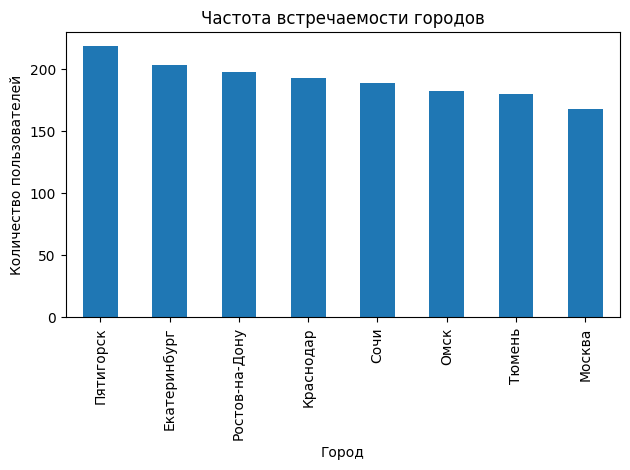

In [19]:
users['city'].value_counts().plot(kind='bar')

plt.title("Частота встречаемости городов")
plt.xlabel("Город")
plt.ylabel("Количество пользователей")
plt.tight_layout()

Наибольшее количество пользователей сервиса зарегистрировано в Пятигорске (219 человек). Наименьшее количество пользователей представлено в Москве (168 человек). Распределение пользователей по городам достаточно равномерное, значительного перекоса в сторону одного города не наблюдается.

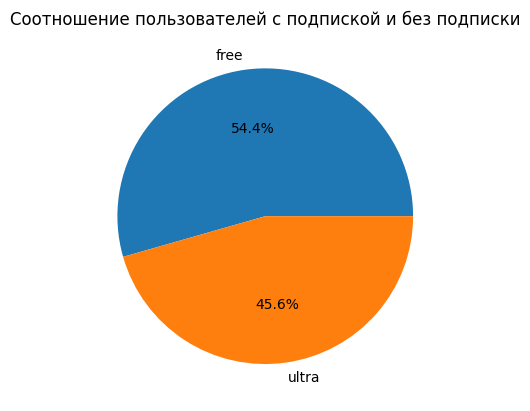

In [20]:
users['subscription_type'].value_counts().plot(kind='pie', autopct='%.1f%%')
plt.title('Соотношение пользователей с подпиской и без подписки')
plt.ylabel("")
plt.show()

Пользователи без подписки составляют около 54,4% аудитории сервиса, пользователи с подпиской Ultra около 45,6%. Распределение близко к равномерному, однако небольшой перевес наблюдается в пользу пользователей без подписки.

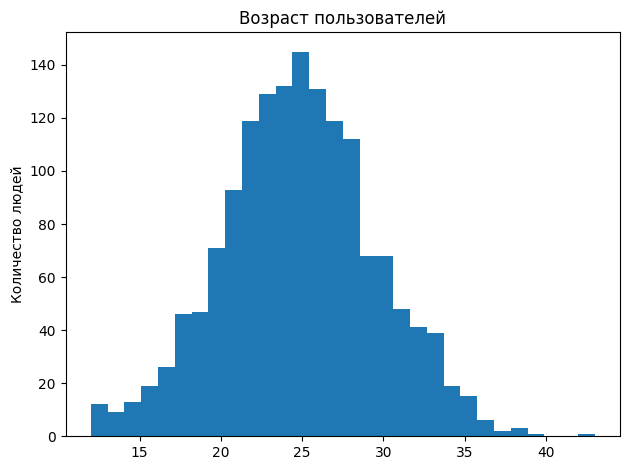

In [21]:
plt.hist(users['age'], bins=30)
plt.title('Возраст пользователей')
plt.ylabel('Количество людей')
plt.tight_layout()

Большинство пользователей находятся в возрасте от 22 до 28 лет, медианный возраст составляет 25 лет. Распределение близко к симметричному с максимумом около 25 лет. В выборке присутствуют пользователи от 12 до 43 лет.

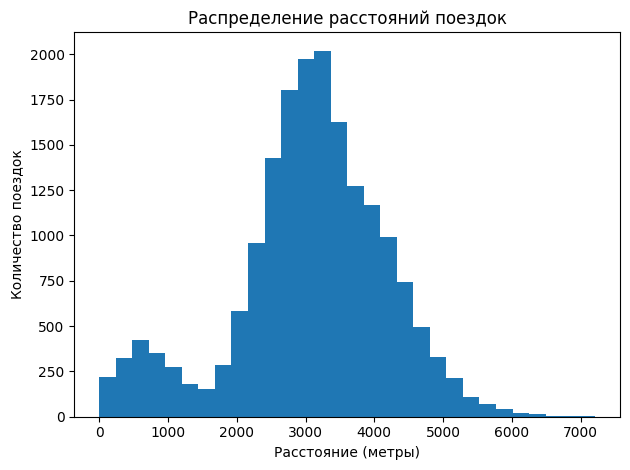

In [22]:
plt.hist(rides['distance'], bins=30)
plt.title('Распределение расстояний поездок')
plt.xlabel('Расстояние (метры)')
plt.ylabel('Количество поездок')
plt.tight_layout()

Наиболее часто пользователи проезжают за одну поездку около 3 км. Большая часть поездок находится в диапазоне от 2,5 до 4 км. В данных присутствуют как очень короткие поездки длиной менее 10 метров, так и длинные поездки протяжённостью более 7 км, что может быть связано с особенностями использования сервиса или техническими особенностями фиксации поездок.

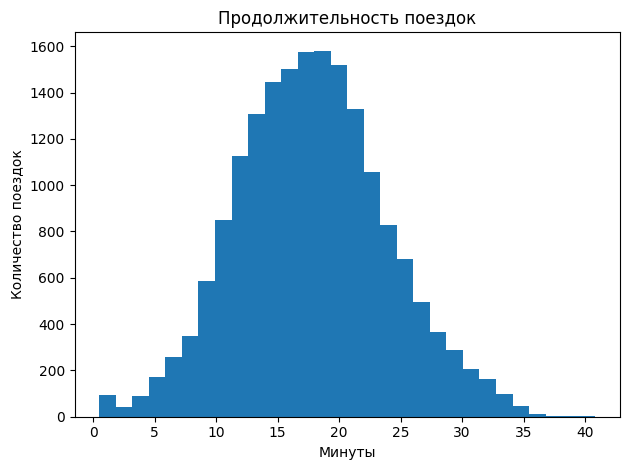

In [23]:
plt.hist(rides['duration'], bins=30)
plt.title('Продолжительность поездок')
plt.xlabel('Минуты')
plt.ylabel('Количество поездок')
plt.tight_layout()

Большинство поездок продолжаются от 13 до 22 минут. Наиболее часто встречаются поездки длительностью около 18 минут. В данных присутствуют как очень короткие поездки продолжительностью менее минуты, так и длительные поездки продолжительностью более 40 минут.

## Объединение данных

In [24]:
merged_data = users.merge(rides, on='user_id', how='left')
merged_data = merged_data.merge(subscriptions, on='subscription_type', how='left')
merged_data.head()

,user_id,name,age,city,subscription_type,distance,duration,date,month,minute_price,start_ride_price,subscription_fee
0,1,Кира,22,Тюмень,ultra,4409.919140,25.599769,2021-01-01,1,6,0,199
1,1,Кира,22,Тюмень,ultra,2617.592153,15.816871,2021-01-18,1,6,0,199
2,1,Кира,22,Тюмень,ultra,754.159807,6.232113,2021-04-20,4,6,0,199
3,1,Кира,22,Тюмень,ultra,2694.783254,18.511000,2021-08-11,8,6,0,199
4,1,Кира,22,Тюмень,ultra,4028.687306,26.265803,2021-08-28,8,6,0,199


In [25]:
merged_data.shape

(18068, 12)

Создадим ещё два датафрейма: c данными о пользователях без подписки и с данными о пользователях с подпиской.

In [26]:
ultra_users = merged_data[merged_data['subscription_type']=='ultra']
free_users = merged_data[merged_data['subscription_type']=='free']

ultra_users.shape, free_users.shape

((6500, 12), (11568, 12))

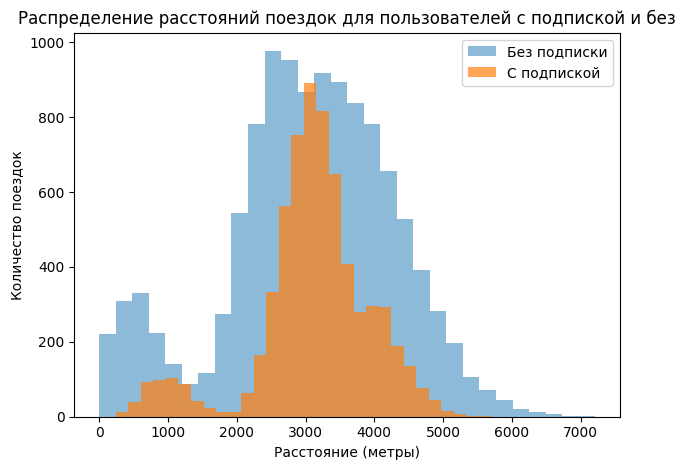

In [27]:
plt.hist(free_users['distance'], alpha=0.5, bins=30, label='Без подписки')
plt.hist(ultra_users['distance'], alpha=0.7, bins=30, label='С подпиской')

plt.title('Распределение расстояний поездок для пользователей с подпиской и без')
plt.xlabel('Расстояние (метры)')
plt.ylabel('Количество поездок')
plt.legend()

plt.tight_layout()

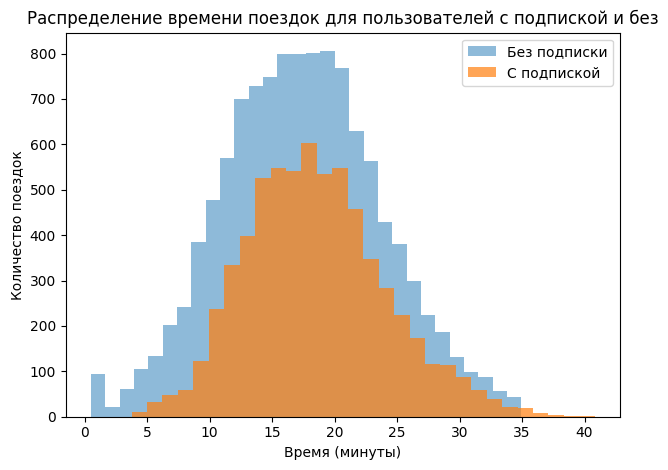

In [28]:
plt.hist(free_users['duration'], alpha=0.5, bins=30, label='Без подписки')
plt.hist(ultra_users['duration'], alpha=0.7, bins=30, label='С подпиской')

plt.title('Распределение времени поездок для пользователей с подпиской и без')
plt.xlabel('Время (минуты)')
plt.ylabel('Количество поездок')
plt.legend()

plt.tight_layout()

Пользователи обеих категорий совершают поездки схожей продолжительности и на схожие расстояния. Однако среди пользователей с подпиской наблюдается более выраженная концентрация поездок около 3 км, что может быть связано с особенностями использования сервиса постоянными клиентами. Для проверки наличия статистически значимых различий требуется проведение дополнительного анализа.

## Подсчёт выручки

In [29]:
merged_data.columns

Index(['user_id', 'name', 'age', 'city', 'subscription_type', 'distance',
       'duration', 'date', 'month', 'minute_price', 'start_ride_price',
       'subscription_fee'],
      dtype='str')

Продолжительность каждой поездки в каждой строке исходного датафрейма для подсчёта стоимости округляется до следующего целого числа. 

In [30]:
merged_data['duration'] = np.ceil(merged_data['duration'])

Создадим датафрейм с агрегированными данными о поездках на основе датафрейма с объединёнными данными.  
Найдем суммарное расстояние, количество поездок и суммарное время для каждого пользователя за каждый месяц

In [31]:
agg_data = merged_data.groupby(['user_id', 'month']).agg({'distance': ['sum', 'count'], 
                                                          'duration': 'sum', 
                                                          'minute_price': 'first',
                                                          'start_ride_price': 'first',
                                                          'subscription_fee': 'first'})\
                                                    .round(2)


agg_data.columns = ['sum_distance', 'cnt_rides', 'sum_duration', 'minute_price', 'start_ride_price', 'subscription_fee']

agg_data.head(10)

sum_distance  cnt_rides  sum_duration  minute_price  \
user_id month                                                        
1       1           7027.51          2          42.0             6   
        4            754.16          1           7.0             6   
        8           6723.47          2          46.0             6   
        10          5809.91          2          32.0             6   
        11          7003.50          3          56.0             6   
        12          6751.63          2          28.0             6   
2       3          10187.72          3          63.0             6   
        4           6164.38          2          40.0             6   
        6           3255.34          1          14.0             6   
        7           6780.72          2          48.0             6   

               start_ride_price  subscription_fee  
user_id month                                      
1       1                     0               199  
        4                     0               199  
        8                     0               199  
        10                    0               199  
        11                    0               199  
        12                    0               199  
2       3                     0               199  
        4                     0               199  
        6                     0               199  
        7                     0               199

Добавим столбец с помесячной выручкой, которую принёс каждый пользователь. 

In [33]:
agg_data['revenue'] = agg_data['sum_duration'] * agg_data['minute_price'] + agg_data['start_ride_price'] * agg_data['cnt_rides'] + agg_data['subscription_fee']
agg_data['revenue']

user_id  month
1        1        451.0
         4        241.0
         8        475.0
         10       391.0
         11       535.0
                  ...  
1534     6        308.0
         8        484.0
         9        234.0
         11       824.0
         12       178.0
Name: revenue, Length: 11331, dtype: float64

Для каждого пользователя была рассчитана ежемесячная выручка с учётом условий тарифа. В расчётах продолжительность каждой поездки была округлена вверх до целого количества минут в соответствии с условиями задания.

## Проверка гипотез

Продакт-менеджеры сервиса хотят увеличить количество пользователей с подпиской. Для этого они будут проводить различные акции, но сначала нужно выяснить несколько важных моментов.

### Гипотеза 1
Тратят ли пользователи с подпиской больше времени на поездки? Если да, то пользователи с подпиской могут быть «выгоднее» для компании.

H0: mu_duration_ultra = mu_duration_free

H1: mu_duration_ultra > mu_duration_free

In [34]:
mu_ultra = ultra_users['duration'].mean().round(2)
mu_free = free_users['duration'].mean().round(2)

print('Среднее первой выборки: ', mu_ultra)
print('Среднее второй выборки: ', mu_free)

Среднее первой выборки:  18.54
Среднее второй выборки:  17.39


In [35]:
print('Дисперсия первой выборки: ', round(ultra_users['duration'].std(), 2))
print('Дисперсия второй выборки: ', round(free_users['duration'].std(), 2))

Дисперсия первой выборки:  5.57
Дисперсия второй выборки:  6.33


In [ ]:
alpha = 0.05

result = st.ttest_ind(ultra_users['duration'], 
             free_users['duration'], 
             alternative='greater')

print('p-value:', result.pvalue)

if result.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не отвергаем нулевую гипотезу')

p-value: 1.280409831664567e-34
Отвергаем нулевую гипотезу


Полученное значение p-value меньше уровня значимости 0,05. Нулевая гипотеза отвергается. Есть статистически значимые основания считать, что пользователи с подпиской Ultra в среднем совершают более длительные поездки, чем пользователи без подписки.

### Гипотеза 2

Расстояние одной поездки в 3130 метров — оптимальное с точки зрения износа самоката. Можно ли сказать, что среднее расстояние, которое проезжают пользователи с подпиской за одну поездку, не превышает 3130 метров?

H0: mu_distance_ultra = 3130

H1: mu_distance_ultra > 3130

In [37]:
mu_ultra = ultra_users['distance'].mean().round(2)

print('Среднее выборки: ', mu_ultra)

Среднее выборки:  3115.45


In [38]:
print('Дисперсия выборки: ', round(ultra_users['distance'].std(), 2))

Дисперсия выборки:  836.9


In [39]:
alpha = 0.05

value = 3130

result = st.ttest_1samp(ultra_users['distance'], 
                        value,
                        alternative='greater')

print('p-value:', result.pvalue)

if result.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не отвергаем нулевую гипотезу')

p-value: 0.9195368847849785
Не отвергаем нулевую гипотезу


Значение p-value больше уровня значимости 0,05, поэтому нулевая гипотеза не отвергается. Полученные результаты не дают статистически значимых оснований утверждать, что среднее расстояние одной поездки пользователей с подпиской превышает 3130 метров. Следовательно, данные не противоречат предположению о том, что среднее расстояние находится на уровне 3130 метров или ниже.

### Гипотеза 3

Будет ли помесячная выручка от пользователей с подпиской по месяцам выше, чем выручка от пользователей без подписки?

h0: revenue_ultra = revenue_free

h1: revenue_ultra > revenue_free

In [41]:
agg_data_ultra = agg_data[agg_data['start_ride_price']==0]
agg_data_free = agg_data[agg_data['start_ride_price']!=0]

mu_ultra = agg_data_ultra['revenue'].mean().round(2)
mu_free = agg_data_free['revenue'].mean().round(2)

print('Среднее первой выборки: ', mu_ultra)
print('Среднее второй выборки: ', mu_free)

Среднее первой выборки:  362.79
Среднее второй выборки:  328.64


In [42]:
print('Дисперсия первой выборки: ', round(agg_data_ultra['revenue'].std(), 2))
print('Дисперсия второй выборки: ', round(agg_data_free['revenue'].std(), 2))

Дисперсия первой выборки:  88.26
Дисперсия второй выборки:  183.87


In [43]:
alpha = 0.05

result = st.ttest_ind(agg_data_ultra['revenue'],
                      agg_data_free['revenue'],
                      alternative='greater',
                      equal_var=False
                      )

print('p-value:', result.pvalue)

if result.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не отвергаем нулевую гипотезу')

p-value: 8.874140893976886e-40
Отвергаем нулевую гипотезу


Значение p-value меньше уровня значимости 0,05. Нулевая гипотеза отвергается. Можно сделать вывод, что пользователи с подпиской Ultra приносят сервису более высокую ежемесячную выручку по сравнению с пользователями без подписки.

### Гипотеза 4

Представим такую ситуацию: техническая команда сервиса обновила сервера, с которыми взаимодействует мобильное приложение. Она надеется, что из-за этого количество обращений в техподдержку значимо снизилось. Некоторый файл содержит для каждого пользователя данные о количестве обращений до обновления и после него. 

В данной ситуации необходимо использовать парный t-тест (scipy.stats.ttest_rel), поскольку количество обращений до и после обновления измеряется для одних и тех же пользователей. Такой тест позволяет проверить наличие статистически значимого изменения среднего количества обращений после обновления серверов.

## Распределения

Отделу маркетинга GoFast поставили задачу: нужно провести акцию с раздачей промокодов на один бесплатный месяц подписки, в рамках которой как минимум 100 существующих клиентов должны продлить эту подписку. То есть по завершении периода действия подписки пользователь может либо отказаться от неё, либо продлить, совершив соответствующий платёж. 


Эта акция уже проводилась ранее и по итогу выяснилось, что после бесплатного пробного периода подписку продлевают 10 % пользователей. Выясните, какое минимальное количество промокодов нужно разослать, чтобы вероятность не выполнить план была примерно 5 %.

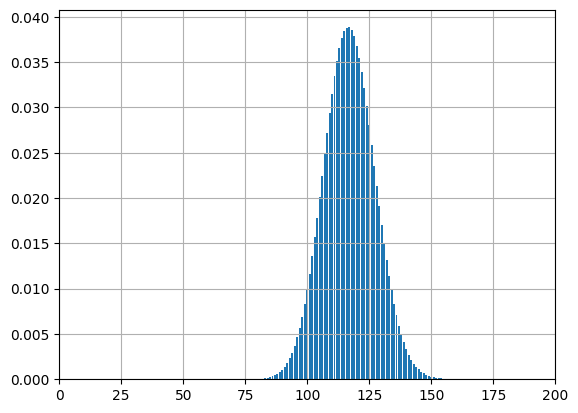

In [44]:
from scipy.stats import binom

n = 1170 # подбираем количество попыток
p = 0.1 # вероятность успеха

distr = []

for k in range(0, n + 1):
    current_value = binom.pmf(k, n, p)
    distr.append(current_value)

plt.bar(range(0, n + 1), distr)
plt.xlim((0, 200))
plt.grid(True)
plt.show()

In [45]:
distr = binom(n, p)
print(distr.cdf(100))

0.051514916737416185


Для выполнения плана необходимо, чтобы подписку продлили не менее 100 пользователей. При вероятности продления 10% и количестве промокодов 1170 вероятность получить менее 100 продлений составляет около 5,15%, что близко к требуемому уровню риска. Следовательно, минимально необходимо разослать примерно 1170 промокодов.

Отдел маркетинга рассылает клиентам push-уведомления в мобильном приложении. Клиенты могут открыть его или не открывать. Известно, что уведомления открывают около 40 % получивших клиентов. Отдел планирует разослать 1 млн уведомлений. С помощью аппроксимации построим примерный график распределения и оценим вероятность того, что уведомление откроют не более 399,5 тыс. пользователей.

In [46]:
n = 1000000
p = 0.4

distr = binom(n, p)

left = n * p - 3 * np.sqrt(n * p * (1-p))
right = n * p + 3 * np.sqrt(n * p * (1-p))

if (0 <= left <= n) and (0 <= right <= n):
    print('Можно использовать аппроксимацию')
else:
    print('Нельзя использовать аппроксимацию')

Можно использовать аппроксимацию


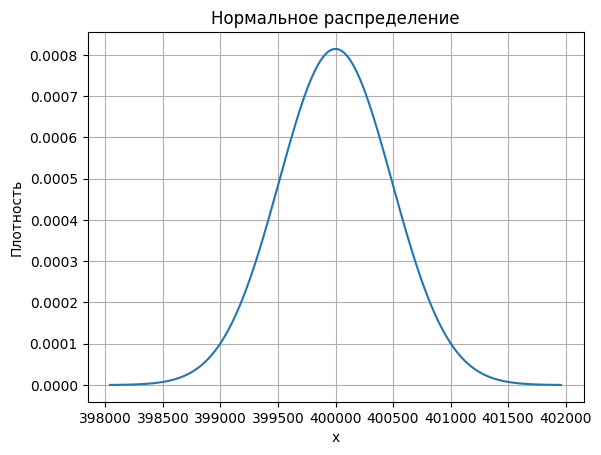

In [47]:
from scipy.stats import norm

mu = n * p
sigma = np.sqrt(n * p * (1-p))

distr = norm(mu, sigma)


# диапазон значений x (от mu - 4*sigma до mu + 4*sigma)
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 500)

# плотность вероятности (PDF)
y = norm.pdf(x, mu, sigma)

plt.plot(x, y)
plt.title("Нормальное распределение")
plt.xlabel("x")
plt.ylabel("Плотность")
plt.grid(True)
plt.show()

In [48]:
print(distr.cdf(399500))

0.15371708296369768


Вероятность того, что уведомление откроют не более 399,5 тыс. пользователей, составляет около 15,4%. Таким образом, вероятность получить результат ниже ожидаемого значения в данном диапазоне относительно невелика.

## Выводы

В ходе исследования были проанализированы данные пользователей сервиса аренды самокатов GoFast, информация об их поездках и тарифах.

На этапе предобработки были устранены дубликаты и подготовлены данные для дальнейшего анализа. Исследование показало, что пользователи сервиса распределены по городам достаточно равномерно, а большинство клиентов находятся в возрасте около 25 лет. Наиболее распространённая длина поездки составляет около 3 км, а типичная продолжительность поездки находится в диапазоне 13–22 минут.

Сравнение пользователей с подпиской Ultra и без подписки показало, что их поведение в целом схоже, однако подписчики чаще совершают поездки оптимальной длины и проводят в поездках больше времени.

Проверка статистических гипотез позволила установить, что пользователи с подпиской Ultra в среднем совершают более длительные поездки. Также не было получено оснований утверждать, что среднее расстояние одной поездки пользователей с подпиской превышает оптимальное для износа самокатов значение 3130 метров. Кроме того, пользователи с подпиской приносят компании статистически значимо более высокую ежемесячную выручку.

Результаты исследования показывают, что развитие и продвижение подписки Ultra может быть выгодным для бизнеса, поскольку подписчики активнее используют сервис и обеспечивают более высокий доход компании.
